# GSS and O*NET Work Styles Visualizations

This notebook explores relationships between individual-level job satisfaction
from the General Social Survey (GSS) and occupation-level O*NET Work Styles.

GSS respondents are linked to O*NET characteristics using `ONET_SOC_CODE`.
The original GSS `SATJOB` variable is coded from 1 = Very satisfied to
4 = Very dissatisfied, so it is reversed here to create a satisfaction score
where higher values indicate greater job satisfaction.

For occupation-level Work Styles analyses, occupations with fewer than
20 respondents are excluded to reduce instability in average satisfaction
estimates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load datasets
gss = pd.read_csv("../../data/constructed_datasets/gss.csv")

work_styles = pd.read_csv(
    "../formatting_onet/formatted_work_styles.csv"
)

print("GSS shape:", gss.shape)
print("Work Styles shape:", work_styles.shape)

GSS shape: (75699, 61)
Work Styles shape: (891, 46)


In [2]:
# Merge GSS respondents with O*NET Work Styles
merged = gss.merge(
    work_styles,
    on="ONET_SOC_CODE",
    how="inner",
    validate="many_to_one"
)

# Keep respondents with valid job satisfaction responses
analysis_df = merged[
    merged["SATJOB"].isin([1, 2, 3, 4])
].copy()

# Reverse SATJOB so higher values mean greater satisfaction
analysis_df["satisfaction_score"] = 5 - analysis_df["SATJOB"]

satisfaction_labels = {
    1: "Very dissatisfied",
    2: "A little dissatisfied",
    3: "Moderately satisfied",
    4: "Very satisfied"
}

analysis_df["satisfaction_label"] = (
    analysis_df["satisfaction_score"]
    .map(satisfaction_labels)
)

print("Rows available for analysis:", len(analysis_df))
print("Unique occupations:", analysis_df["ONET_SOC_CODE"].nunique())

analysis_df[
    ["SATJOB", "satisfaction_score", "satisfaction_label"]
].head()

Rows available for analysis: 48765
Unique occupations: 488


,SATJOB,satisfaction_score,satisfaction_label
0,3.0,2.0,A little dissatisfied
2,2.0,3.0,Moderately satisfied
3,1.0,4.0,Very satisfied
5,2.0,3.0,Moderately satisfied
6,1.0,4.0,Very satisfied


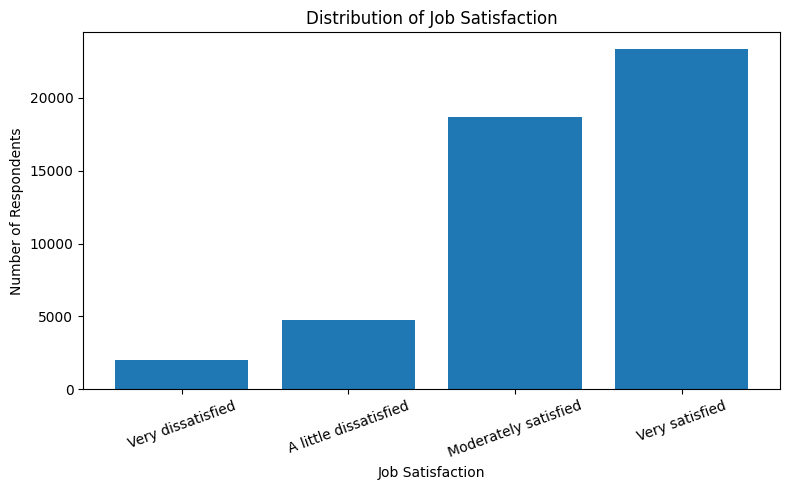

In [3]:
satisfaction_counts = (
    analysis_df["satisfaction_score"]
    .value_counts()
    .sort_index()
)

labels = [
    "Very dissatisfied",
    "A little dissatisfied",
    "Moderately satisfied",
    "Very satisfied"
]

plt.figure(figsize=(8, 5))

plt.bar(labels, satisfaction_counts.values)

plt.title("Distribution of Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

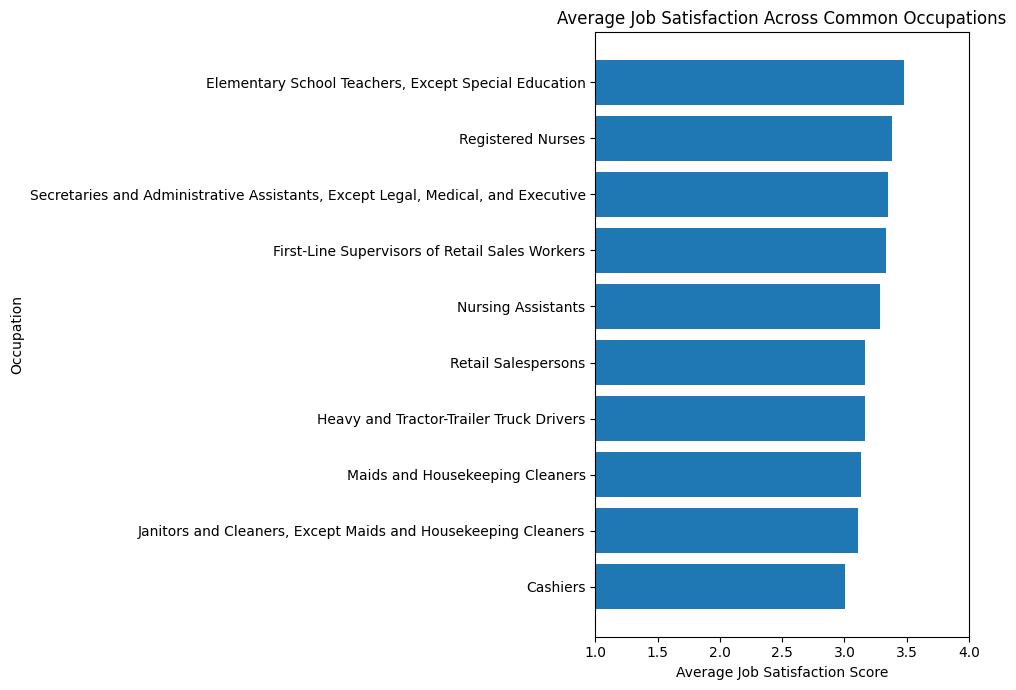

,mean,count
title,,
Cashiers,3.003571,840
"Janitors and Cleaners, Except Maids and Housekeeping Cleaners",3.112183,829
Maids and Housekeeping Cleaners,3.136569,886
Heavy and Tractor-Trailer Truck Drivers,3.162411,979
Retail Salespersons,3.168282,1135
Nursing Assistants,3.285849,1060
First-Line Supervisors of Retail Sales Workers,3.336653,1004
"Secretaries and Administrative Assistants, Except Legal, Medical, and Executive",3.352376,1978
Registered Nurses,3.383777,826


In [4]:
top_occupations = (
    analysis_df["title"]
    .value_counts()
    .head(10)
    .index
)

occupation_summary = (
    analysis_df[
        analysis_df["title"].isin(top_occupations)
    ]
    .groupby("title")["satisfaction_score"]
    .agg(["mean", "count"])
    .sort_values("mean")
)

plt.figure(figsize=(10, 7))

plt.barh(
    occupation_summary.index,
    occupation_summary["mean"]
)

plt.title("Average Job Satisfaction Across Common Occupations")
plt.xlabel("Average Job Satisfaction Score")
plt.ylabel("Occupation")

plt.xlim(1, 4)
plt.tight_layout()
plt.show()

occupation_summary

In [5]:
# Work Styles Impact columns
impact_cols = [
    col for col in analysis_df.columns
    if col.startswith("work_styles_impact_")
    and col.endswith("_value")
]

print("Number of Work Styles:", len(impact_cols))

Number of Work Styles: 21


In [6]:
# Average satisfaction for each occupation
occupation_satisfaction = (
    analysis_df
    .groupby(["ONET_SOC_CODE", "title"])["satisfaction_score"]
    .agg(
        mean_satisfaction="mean",
        n_respondents="count"
    )
    .reset_index()
)

# O*NET Work Styles values are constant within each occupation,
# so keep one copy per occupation
occupation_styles = (
    analysis_df
    .groupby(["ONET_SOC_CODE", "title"])[impact_cols]
    .first()
    .reset_index()
)

occupation_level = occupation_satisfaction.merge(
    occupation_styles,
    on=["ONET_SOC_CODE", "title"],
    how="inner"
)

# Keep occupations with at least 20 respondents
# so occupation-level averages are less unstable
occupation_level = occupation_level[
    occupation_level["n_respondents"] >= 20
].copy()

print("Occupations used:", len(occupation_level))
occupation_level.head()

Occupations used: 319


,ONET_SOC_CODE,title,mean_satisfaction,n_respondents,work_styles_impact_achievement_orientation_value,work_styles_impact_adaptability_value,work_styles_impact_attention_to_detail_value,work_styles_impact_cautiousness_value,work_styles_impact_cooperation_value,work_styles_impact_dependability_value,...,work_styles_impact_intellectual_curiosity_value,work_styles_impact_leadership_orientation_value,work_styles_impact_optimism_value,work_styles_impact_perseverance_value,work_styles_impact_self_confidence_value,work_styles_impact_self_control_value,work_styles_impact_sincerity_value,work_styles_impact_social_orientation_value,work_styles_impact_stress_tolerance_value,work_styles_impact_tolerance_for_ambiguity_value
0,11-1011.00,Chief Executives,3.640138,289,2.91,2.69,1.44,1.03,1.53,2.93,...,2.16,3.00,1.60,2.46,2.69,2.42,0.96,2.26,2.55,2.05
1,11-1021.00,General and Operations Managers,3.452206,272,2.38,2.05,1.74,1.32,1.84,2.65,...,1.44,2.93,1.39,2.19,2.28,2.14,0.94,1.97,1.99,1.64
3,11-2011.00,Advertising and Promotions Managers,3.666667,30,2.31,2.13,1.86,-0.44,1.84,2.22,...,1.44,2.52,1.63,1.77,2.24,1.37,0.57,2.45,1.80,1.72
4,11-2022.00,Sales Managers,3.402027,296,2.45,2.02,1.67,0.24,1.77,2.47,...,1.17,2.71,1.71,2.46,2.40,1.91,0.94,2.54,1.93,1.51
5,11-2032.00,Public Relations Managers,3.323529,34,2.21,2.30,1.89,0.90,2.69,2.56,...,1.57,2.46,2.22,1.97,2.40,2.18,1.55,2.60,2.21,1.74


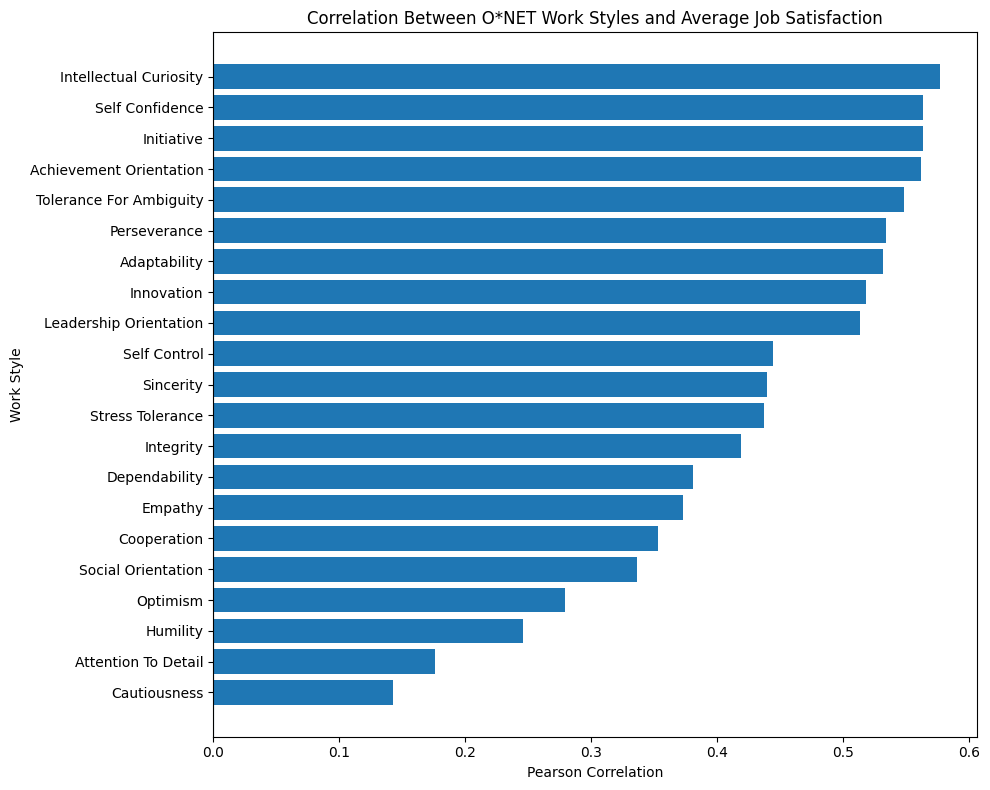

work_styles_impact_cautiousness_value               0.142853
work_styles_impact_attention_to_detail_value        0.176452
work_styles_impact_humility_value                   0.245654
work_styles_impact_optimism_value                   0.279408
work_styles_impact_social_orientation_value         0.336662
work_styles_impact_cooperation_value                0.352927
work_styles_impact_empathy_value                    0.372892
work_styles_impact_dependability_value              0.381247
work_styles_impact_integrity_value                  0.418731
work_styles_impact_stress_tolerance_value           0.437258
work_styles_impact_sincerity_value                  0.439637
work_styles_impact_self_control_value               0.444244
work_styles_impact_leadership_orientation_value     0.513360
work_styles_impact_innovation_value                 0.518520
work_styles_impact_adaptability_value               0.531715
work_styles_impact_perseverance_value               0.534416
work_styles_impact_toler

In [7]:
correlations = (
    occupation_level[impact_cols]
    .corrwith(occupation_level["mean_satisfaction"])
    .sort_values()
)

# Make names easier to read
correlation_labels = [
    col
    .replace("work_styles_impact_", "")
    .replace("_value", "")
    .replace("_", " ")
    .title()
    for col in correlations.index
]

plt.figure(figsize=(10, 8))

plt.barh(
    correlation_labels,
    correlations.values
)

plt.axvline(0)

plt.title(
    "Correlation Between O*NET Work Styles "
    "and Average Job Satisfaction"
)
plt.xlabel("Pearson Correlation")
plt.ylabel("Work Style")

plt.tight_layout()
plt.show()

correlations

In [8]:
# Find the Work Style with the strongest absolute correlation
strongest_style = correlations.abs().idxmax()

strongest_corr = correlations[strongest_style]

style_label = (
    strongest_style
    .replace("work_styles_impact_", "")
    .replace("_value", "")
    .replace("_", " ")
    .title()
)

print("Strongest Work Style:", style_label)
print("Correlation:", round(strongest_corr, 3))

Strongest Work Style: Intellectual Curiosity
Correlation: 0.577


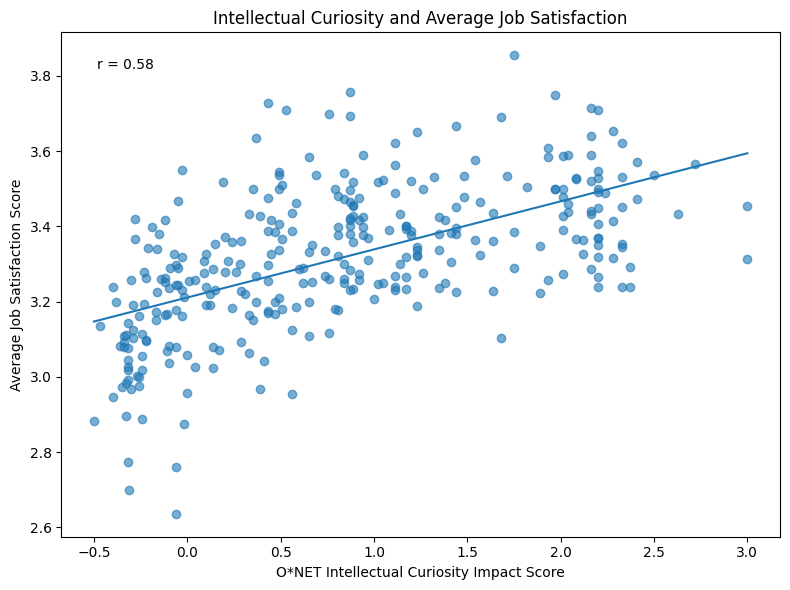

In [9]:
x = occupation_level[strongest_style]
y = occupation_level["mean_satisfaction"]

plt.figure(figsize=(8, 6))

plt.scatter(x, y, alpha=0.6)

# Add a simple trend line
m, b = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = m * x_line + b

plt.plot(x_line, y_line)

plt.title(
    f"{style_label} and Average Job Satisfaction"
)
plt.xlabel(f"O*NET {style_label} Impact Score")
plt.ylabel("Average Job Satisfaction Score")

plt.text(
    0.05,
    0.95,
    f"r = {strongest_corr:.2f}",
    transform=plt.gca().transAxes,
    verticalalignment="top"
)

plt.tight_layout()
plt.show()

## Key Observations

- Most respondents in the analysis report being moderately or very satisfied with their jobs.
- Average job satisfaction varies somewhat across the most common occupations in the dataset.
- Several O*NET Work Styles show positive correlations with occupation-level average job satisfaction.
- Intellectual Curiosity has the strongest observed relationship in this exploratory analysis (`r ≈ 0.58`).
- These results are descriptive correlations and should not be interpreted as causal relationships.